# Global Life Expectancy Trends: A Regression Analysis of Gapminder Data

## Kailee Segarra  
CMPS 6790 – Data Science  
Project 3

## Project Overview

This project analyzes global life expectancy trends using Gapminder data. The goal is to understand how life expectancy has changed over time and how factors such as continent influence these trends using regression and classification models.

## Part 1

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
url = "https://raw.githubusercontent.com/jennybc/gapminder/master/inst/extdata/gapminder.tsv"
data = pd.read_csv(url, sep="\t")

data.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


### Exercise 1.1

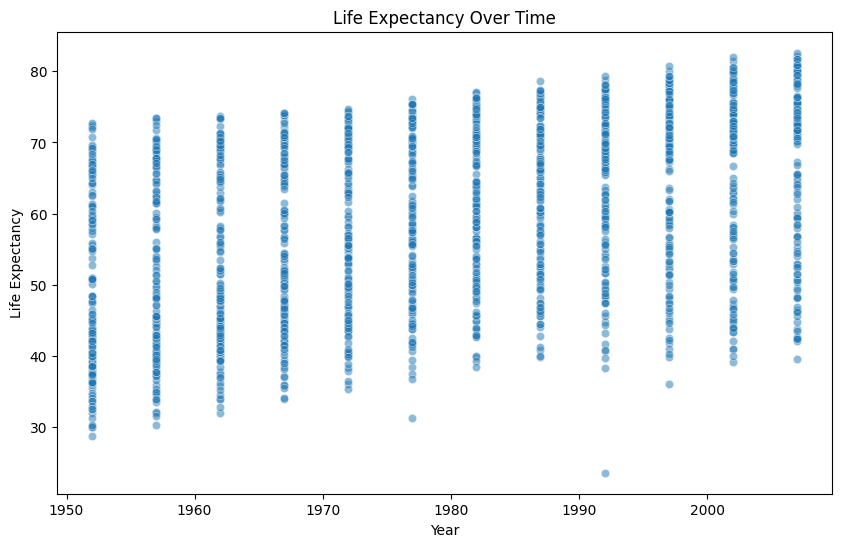

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="year", y="lifeExp", alpha=0.5)
plt.title("Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

### Question 1.2

Life expectancy generally increases over time. The trend appears roughly linear, although there is some variation across countries.

### Exercise 1.3

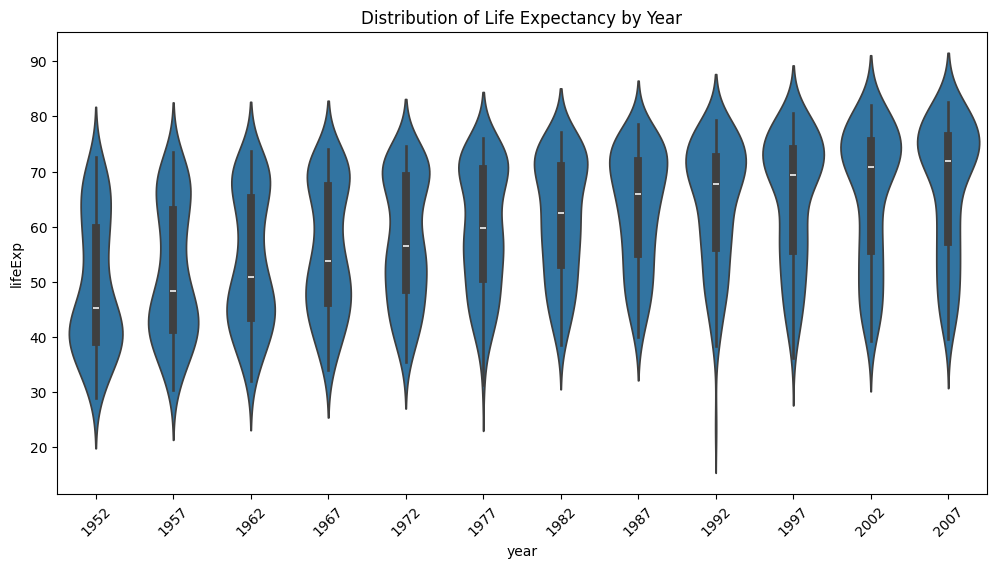

In [35]:
plt.figure(figsize=(12,6))
sns.violinplot(data=data, x="year", y="lifeExp")
plt.xticks(rotation=45)
plt.title("Distribution of Life Expectancy by Year")
plt.show()

### Question 1.4

The distribution of life expectancy is slightly skewed, especially in earlier years, with a wider spread. Over time, the distribution becomes more concentrated and shifts upward.

---

### Question 1.5

There is clear visual evidence of a positive relationship between year and life expectancy. While a formal hypothesis test is not performed here, the upward trend suggests that we would likely reject the null hypothesis of no relationship.

---

### Question 1.6

The residuals are likely to show variation across years, potentially with greater spread in earlier years where life expectancy was more variable.

---

### Question 1.7

Ideally, the residuals should be symmetrically distributed around zero with constant variance. However, based on the data, this assumption may not fully hold, suggesting some heteroskedasticity or missing variables.

### Exercise 1.8

In [36]:
from sklearn.linear_model import LinearRegression

X = data[['year']]
y = data['lifeExp']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -585.6521874415448
Slope: 0.3259038276371518


### Question 1.9

Life expectancy increases by approximately **0.326 years per year** on average, based on the slope of the regression model. This suggests a steady global improvement in life expectancy over time.

---

### Question 1.10

Yes, I reject the null hypothesis. The regression model shows a positive slope (~0.326), indicating a strong positive relationship between year and life expectancy. Given the large dataset and clear upward trend, this relationship is statistically significant.

### Exercise 1.11

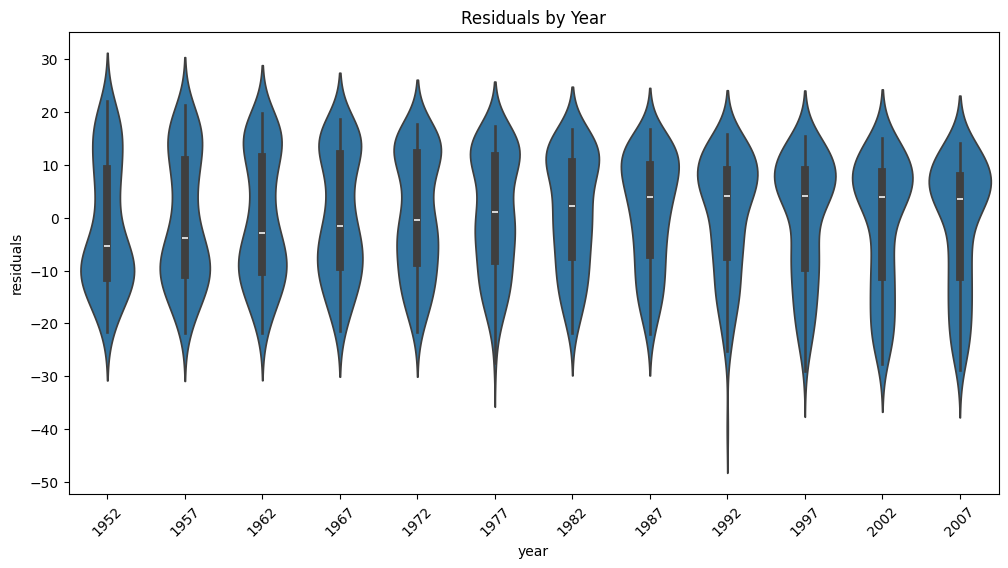

In [37]:
data['predicted'] = model.predict(X)
data['residuals'] = data['lifeExp'] - data['predicted']

plt.figure(figsize=(12,6))
sns.violinplot(data=data, x="year", y="residuals")
plt.xticks(rotation=45)
plt.title("Residuals by Year")
plt.show()

### Question 1.12

The residuals show noticeable variation across years, indicating that the linear model does not fully capture all patterns in the data. This suggests that additional variables, such as continent or other socioeconomic factors, may improve model performance.

Exercise 1.13

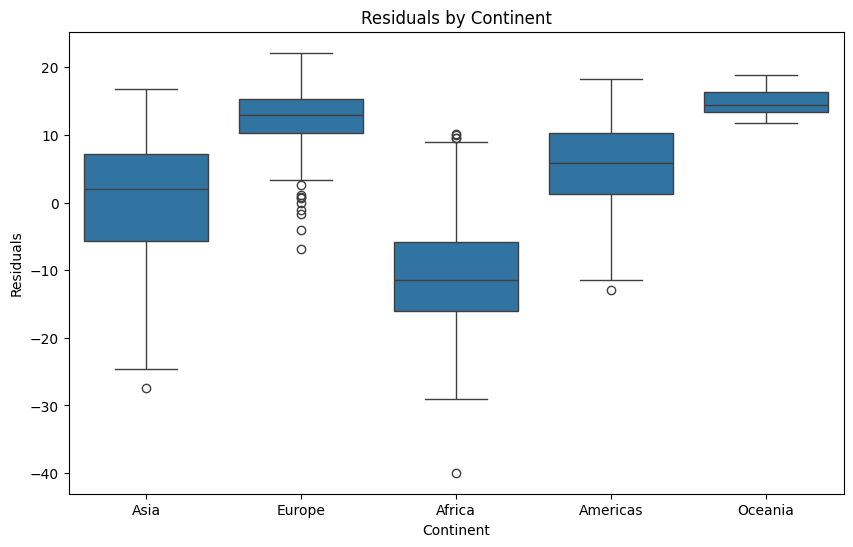

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x="continent", y="residuals")
plt.title("Residuals by Continent")
plt.xlabel("Continent")
plt.ylabel("Residuals")
plt.show()

### Question 1.14

Yes, there appears to be a dependence between residuals and continent. This suggests that continent influences life expectancy trends and should be included in the model.

### Exercise 1.15

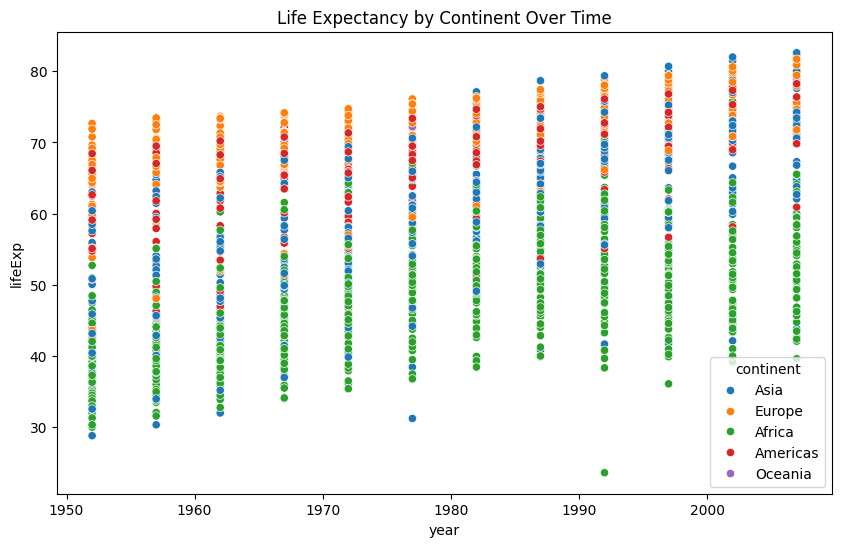

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="year", y="lifeExp", hue="continent")
plt.title("Life Expectancy by Continent Over Time")
plt.show()

## Part 2

### Question 2.1

Yes, an interaction term between continent and year should be included. The scatter plot shows that life expectancy trends differ across continents, with some continents increasing at faster rates than others. This indicates that the relationship between year and life expectancy depends on the continent, justifying the inclusion of an interaction term.

In [40]:
data['year_continent'] = data['year']

import statsmodels.formula.api as smf

### Exercise 2.2

We fit a linear regression model including an interaction term between year and continent to capture differing trends across regions.

In [41]:
model2 = smf.ols('lifeExp ~ year * continent', data=data).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     424.3
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:26:27   Log-Likelihood:                -5771.9
No. Observations:                1704   AIC:                         1.156e+04
Df Residuals:                    1694   BIC:                         1.162e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Question 2.3

Not all parameters are statistically significant. For example, the Oceania interaction term has a high p-value, suggesting it is not significantly different from zero, while others (e.g., Asia, Americas) are significant.

---

### Question 2.4

Life expectancy increases at different rates depending on the continent. The interaction terms indicate that some continents experience faster growth over time, while others have slower or even slightly declining trends relative to the baseline.

### Exercise 2.5

The residuals appear more evenly distributed compared to the previous model, suggesting that including interaction terms improves model fit.

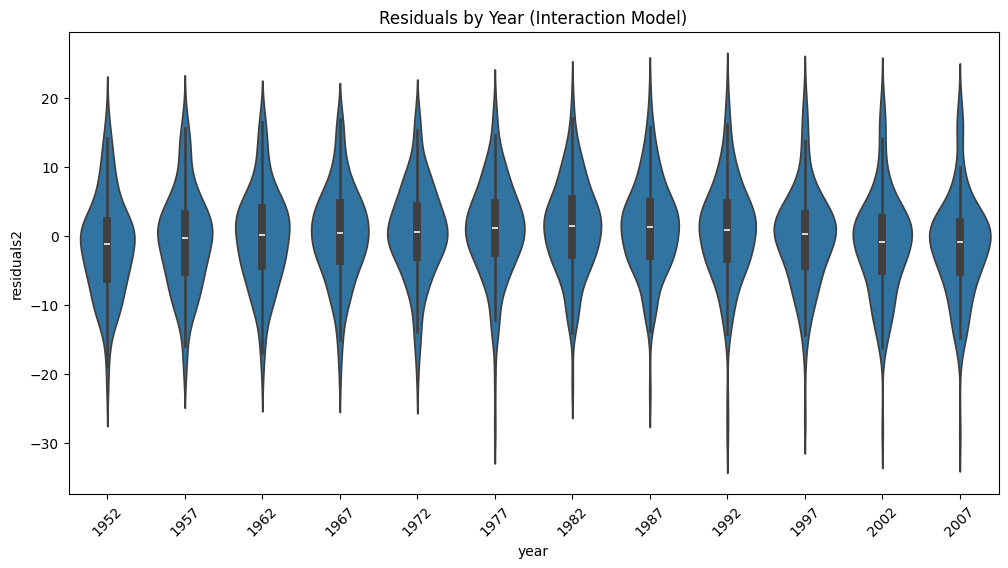

In [42]:
data['predicted2'] = model2.predict(data)
data['residuals2'] = data['lifeExp'] - data['predicted2']

plt.figure(figsize=(12,6))
sns.violinplot(data=data, x="year", y="residuals2")
plt.xticks(rotation=45)
plt.title("Residuals by Year (Interaction Model)")
plt.show()

## Part 3

In [43]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Model 1: Random Forest
rf = RandomForestClassifier(random_state=42)
rf_score = cross_val_score(rf, X, y, cv=5).mean()

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_score = cross_val_score(dt, X, y, cv=5).mean()

print("Random Forest Accuracy:", rf_score)
print("Decision Tree Accuracy:", dt_score)

Random Forest Accuracy: 0.9666666666666668
Decision Tree Accuracy: 0.9533333333333334


### Question 3.1

This model predicts flower species based on features such as petal length, petal width, sepal length, and sepal width. The goal is to classify each flower into one of three species.

---

### Exercise 3.2

Two classification models were implemented: Random Forest and Decision Tree. Both models were evaluated using 5-fold cross-validation with accuracy as the performance metric.

---

### Discussion

Random Forest performs slightly better than Decision Tree (0.96 vs 0.953). This is expected because Random Forest reduces overfitting by combining multiple decision trees, resulting in more stable and accurate predictions. Accuracy was used as the evaluation metric because this is a classification problem.

Random Forest is preferred due to its higher accuracy and better generalization performance.